# 02 Main Regression Analysis

## Final Individual Project

**Project topic:** Screen Time and BMI Percentile among High School Students

**Research question:**  
Is there a linear relationship between screen time and BMI percentile among high school students?

This notebook uses **simple linear regression** to examine whether approximate total screen time predicts BMI percentile.

The model is:

```text
BMI percentile = b0 + b1(screen time hours)
```

Where:

- **X variable:** `screen_time_hours`
- **Y variable:** `bmi_percentile`


In [50]:
# Import packages
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
from scipy import stats

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)


## 1. Set project paths

This notebook is designed to be placed inside the `notebooks/` folder.

It uses the cleaned dataset created by:

```text
01_data_cleaning.ipynb
```


In [51]:
# Project paths
project_dir = Path("..").resolve()

processed_dir = project_dir / "data" / "processed"
figures_dir = project_dir / "outputs" / "figures"
tables_dir = project_dir / "outputs" / "tables"
summary_dir = project_dir / "outputs" / "summary"

# Create output folders if needed
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
summary_dir.mkdir(parents=True, exist_ok=True)

cleaned_data_path = processed_dir / "screen_time_bmi_cleaned.csv"

if not cleaned_data_path.exists():
    raise FileNotFoundError(
        "Could not find screen_time_bmi_cleaned.csv. "
        "Please run 01_data_cleaning.ipynb first."
    )

print(f"Using cleaned data file: {cleaned_data_path}")


Using cleaned data file: D:\作業\統計學實習\final individual project\data\processed\screen_time_bmi_cleaned.csv


## 2. Load cleaned data


In [52]:
# Load cleaned dataset
df = pd.read_csv(cleaned_data_path)

print("Cleaned dataset shape:", df.shape)
df.head()


Cleaned dataset shape: (12844, 6)


,TelevisionWatching,ComputerUse,tv_hours,computer_hours,screen_time_hours,bmi_percentile
0,6.0000,3.0000,4.0000,1.0000,5.0000,66.5318
1,1.0000,1.0000,0.0000,0.0000,0.0000,98.1743
2,1.0000,1.0000,0.0000,0.0000,0.0000,33.0755
3,6.0000,2.0000,4.0000,0.5000,4.5000,45.6883
4,4.0000,2.0000,2.0000,0.5000,2.5000,62.3903


## 3. Descriptive statistics

Before fitting the regression model, we summarize the two main variables.


In [53]:
# Main variables
x_var = "screen_time_hours"
y_var = "bmi_percentile"

main_df = df[[x_var, y_var]].dropna().copy()

descriptive_table = main_df.describe().T
descriptive_table


,count,mean,std,min,25%,50%,75%,max
screen_time_hours,12844.0000,3.7670,2.4868,0.0000,2.0000,3.5000,5.0000,10.0000
bmi_percentile,12844.0000,64.8381,27.5137,0.0000,45.1714,70.2007,89.4428,99.9392


In [54]:
# Save descriptive table
descriptive_table.to_csv(tables_dir / "regression_descriptive_statistics.csv")

print("Saved:")
print(tables_dir / "regression_descriptive_statistics.csv")


Saved:
D:\作業\統計學實習\final individual project\outputs\tables\regression_descriptive_statistics.csv


## 4. Research hypotheses

For the simple linear regression model:

```text
BMI percentile = b0 + b1(screen time hours)
```

The hypotheses are:

```text
H0: β1 = 0
H1: β1 ≠ 0
```

Interpretation:

- **H0:** There is no linear relationship between screen time and BMI percentile.
- **H1:** There is a linear relationship between screen time and BMI percentile.


## 5. Fit simple linear regression model


In [55]:
# Define X and Y
X = main_df[[x_var]]
Y = main_df[y_var]

# Add intercept term
X_with_intercept = sm.add_constant(X)

# Fit OLS regression model
model = sm.OLS(Y, X_with_intercept).fit()

# Show full regression summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:         bmi_percentile   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     73.99
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           8.78e-18
Time:                        16:05:33   Log-Likelihood:                -60761.
No. Observations:               12844   AIC:                         1.215e+05
Df Residuals:                   12842   BIC:                         1.215e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                61.6837      0.43

In [56]:
# Save full regression summary as text
with open(summary_dir / "regression_model_summary.txt", "w", encoding="utf-8") as f:
    f.write(model.summary().as_text())

print("Saved:")
print(summary_dir / "regression_model_summary.txt")


Saved:
D:\作業\統計學實習\final individual project\outputs\summary\regression_model_summary.txt


## 6. Extract key regression results

The most important values are:

- intercept
- slope
- p-value for the slope
- 95% confidence interval for the slope
- R-squared


In [57]:
# Extract key results
intercept = model.params["const"]
slope = model.params[x_var]
slope_p_value = model.pvalues[x_var]
r_squared = model.rsquared
adj_r_squared = model.rsquared_adj
n = int(model.nobs)

conf_int = model.conf_int(alpha=0.05)
slope_ci_lower = conf_int.loc[x_var, 0]
slope_ci_upper = conf_int.loc[x_var, 1]

t_stat = model.tvalues[x_var]

key_results = pd.DataFrame({
    "Statistic": [
        "Sample size",
        "Intercept",
        "Slope for screen_time_hours",
        "t statistic for slope",
        "p-value for slope",
        "95% CI lower for slope",
        "95% CI upper for slope",
        "R-squared",
        "Adjusted R-squared"
    ],
    "Value": [
        n,
        intercept,
        slope,
        t_stat,
        slope_p_value,
        slope_ci_lower,
        slope_ci_upper,
        r_squared,
        adj_r_squared
    ]
})

key_results


,Statistic,Value
0,Sample size,12844.0000
1,Intercept,61.6837
2,Slope for screen_time_hours,0.8374
3,t statistic for slope,8.6015
4,p-value for slope,0.0000
5,95% CI lower for slope,0.6466
6,95% CI upper for slope,1.0282
7,R-squared,0.0057
8,Adjusted R-squared,0.0057


In [58]:
# Save key results
key_results.to_csv(tables_dir / "regression_key_results.csv", index=False)

print("Saved:")
print(tables_dir / "regression_key_results.csv")


Saved:
D:\作業\統計學實習\final individual project\outputs\tables\regression_key_results.csv


## 7. Interpretation helper

This cell creates a short interpretation based on the p-value and slope direction.


In [59]:
alpha = 0.05

if slope > 0:
    direction_text = "positive"
    practical_direction = "higher screen time is associated with a higher predicted BMI percentile"
elif slope < 0:
    direction_text = "negative"
    practical_direction = "higher screen time is associated with a lower predicted BMI percentile"
else:
    direction_text = "zero"
    practical_direction = "there is no estimated change in predicted BMI percentile as screen time changes"

if slope_p_value < alpha:
    significance_text = (
        "The p-value is less than 0.05, so we reject the null hypothesis. "
        "There is statistically significant evidence of a linear relationship between screen time and BMI percentile."
    )
else:
    significance_text = (
        "The p-value is greater than 0.05, so we fail to reject the null hypothesis. "
        "There is not enough statistical evidence to conclude that screen time and BMI percentile have a significant linear relationship."
    )

interpretation = f"""
Simple linear regression was used to examine the relationship between screen time and BMI percentile.

The estimated slope is {slope:.4f}. This means that for each additional one hour of screen time,
the predicted BMI percentile changes by about {slope:.4f} percentile points on average.

The slope is {direction_text}, which suggests that {practical_direction}.

The p-value for the slope is {slope_p_value:.4f}. {significance_text}

The R-squared value is {r_squared:.4f}, meaning that screen time explains about {r_squared * 100:.2f}% of the variation in BMI percentile in this sample.

Because this is observational survey data, the result should be interpreted as association, not causation.
"""

print(interpretation)



Simple linear regression was used to examine the relationship between screen time and BMI percentile.

The estimated slope is 0.8374. This means that for each additional one hour of screen time,
the predicted BMI percentile changes by about 0.8374 percentile points on average.

The slope is positive, which suggests that higher screen time is associated with a higher predicted BMI percentile.

The p-value for the slope is 0.0000. The p-value is less than 0.05, so we reject the null hypothesis. There is statistically significant evidence of a linear relationship between screen time and BMI percentile.

The R-squared value is 0.0057, meaning that screen time explains about 0.57% of the variation in BMI percentile in this sample.

Because this is observational survey data, the result should be interpreted as association, not causation.



In [60]:
# Save interpretation
with open(summary_dir / "regression_interpretation.txt", "w", encoding="utf-8") as f:
    f.write(interpretation)

print("Saved:")
print(summary_dir / "regression_interpretation.txt")


Saved:
D:\作業\統計學實習\final individual project\outputs\summary\regression_interpretation.txt


## 8. Main regression figure

This figure shows the relationship between screen time and BMI percentile.

Since screen time was recoded from categories, many points have the same X value.  
A small random jitter is added **only for visualization**.  
The regression model itself still uses the original `screen_time_hours` values.


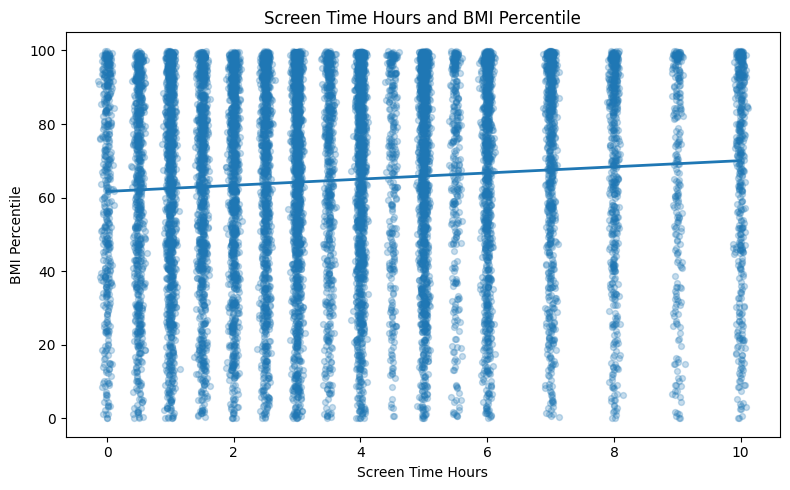

In [61]:
# Create x values for regression line
x_line = np.linspace(main_df[x_var].min(), main_df[x_var].max(), 100)
x_line_with_intercept = sm.add_constant(pd.DataFrame({x_var: x_line}))
y_line = model.predict(x_line_with_intercept)

# Add small jitter only to help visualize overlapping points
np.random.seed(112310326)
x_jitter = main_df[x_var] + np.random.normal(0, 0.04, size=len(main_df))

plt.figure(figsize=(8, 5))
plt.scatter(x_jitter, main_df[y_var], alpha=0.25, s=18)
plt.plot(x_line, y_line, linewidth=2)
plt.xlabel("Screen Time Hours")
plt.ylabel("BMI Percentile")
plt.title("Screen Time Hours and BMI Percentile")
plt.tight_layout()
plt.savefig(figures_dir / "screen_time_bmi_regression_line.png", dpi=300)
plt.show()


**Interpretation:**  
The regression line shows a slight positive trend. This means that higher screen time is associated with a slightly higher predicted BMI percentile. However, the data points are widely spread around the line, so the relationship appears weak in practical terms.

## 9. Residual analysis

Residual plots help check whether the simple linear regression assumptions are reasonable.

We mainly look for:

- no strong curved pattern
- no obvious funnel shape
- no extremely unusual outliers


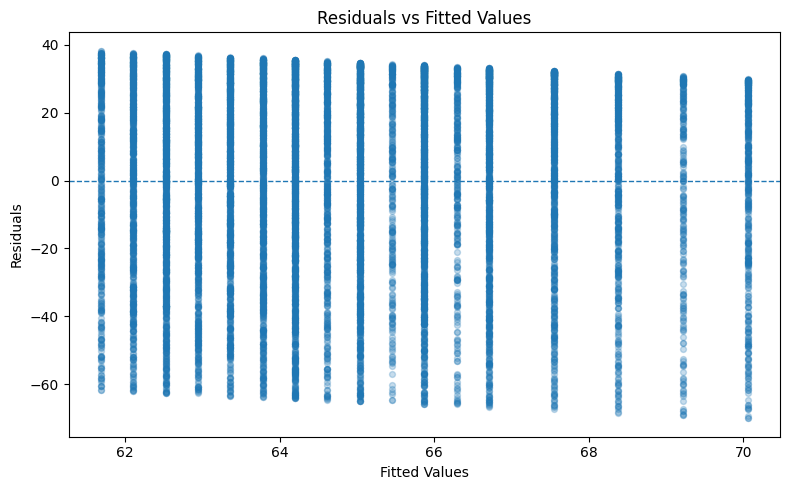

In [62]:
# Fitted values and residuals
main_df["fitted_values"] = model.fittedvalues
main_df["residuals"] = model.resid

plt.figure(figsize=(8, 5))
plt.scatter(main_df["fitted_values"], main_df["residuals"], alpha=0.25, s=18)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.tight_layout()
plt.savefig(figures_dir / "residuals_vs_fitted.png", dpi=300)
plt.show()


**Interpretation:**  
The residual plot shows that residuals are widely spread around zero. This indicates that screen time alone does not predict BMI percentile very accurately. The vertical patterns appear because screen time was recoded from categorical responses, so the fitted values are also grouped.

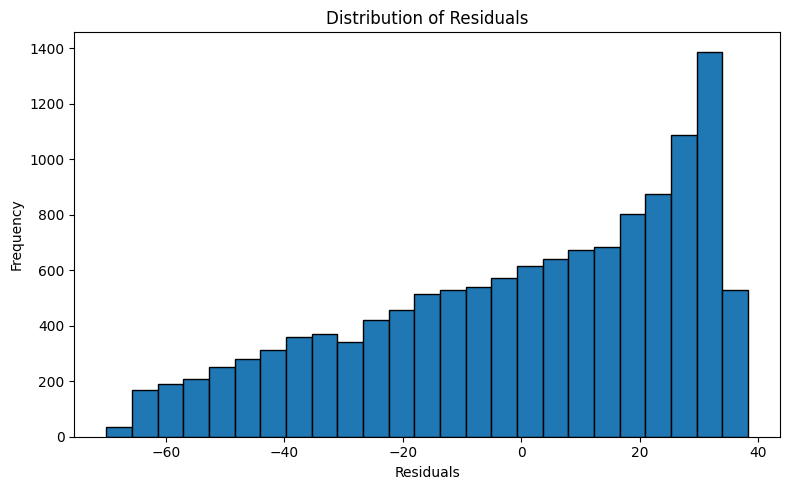

In [63]:
# Histogram of residuals
plt.figure(figsize=(8, 5))
plt.hist(main_df["residuals"], bins=25, edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.tight_layout()
plt.savefig(figures_dir / "residual_distribution.png", dpi=300)
plt.show()


**Interpretation:**  
The residuals are not perfectly normally distributed. The distribution is somewhat skewed, which may be related to the bounded nature of BMI percentile from 0 to 100. This suggests that the normality assumption is not perfectly satisfied.

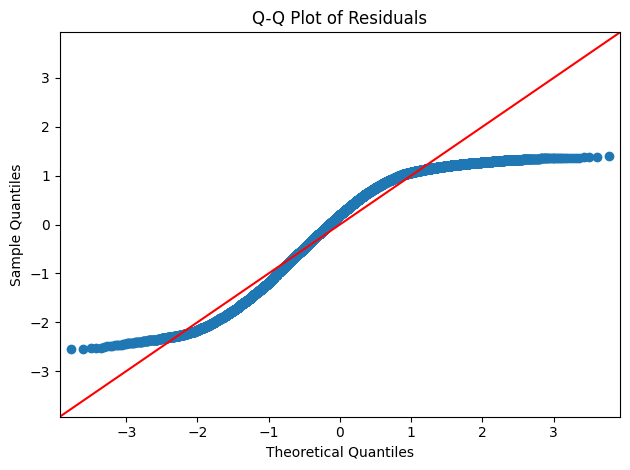

In [64]:
# Q-Q plot for residuals
sm.qqplot(main_df["residuals"], line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.savefig(figures_dir / "residual_qq_plot.png", dpi=300)
plt.show()


**Interpretation:**  
The Q-Q plot shows noticeable deviation from the reference line, especially in the tails. This means the residuals are not perfectly normal. Therefore, the regression result should be interpreted carefully, especially because BMI percentile is bounded and screen time is an approximate recoded variable.

## 10. Save model-ready data with fitted values and residuals


In [65]:
# Save data with fitted values and residuals
model_output_data = main_df.copy()
model_output_data.to_csv(processed_dir / "screen_time_bmi_model_output.csv", index=False)

print("Saved:")
print(processed_dir / "screen_time_bmi_model_output.csv")


Saved:
D:\作業\統計學實習\final individual project\data\processed\screen_time_bmi_model_output.csv


## Overall Interpretation:
The regression analysis found a statistically significant positive relationship between screen time and BMI percentile. The slope was 0.8374, meaning that each additional hour of screen time was associated with an increase of about 0.84 BMI percentile points on average. However, the R-squared value was only 0.0057, meaning that screen time explained only about 0.57% of the variation in BMI percentile. Therefore, although the relationship was statistically significant, the practical effect was weak. Since this is observational survey data, the result should be interpreted as association, not causation.